<a href="https://colab.research.google.com/github/MaGiaVy/DoAnPython/blob/main/project/notebooks/BTCT_Tuan3_33.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## CELL 1: KHỞI TẠO VÀ IMPORT HỆ THỐNG THƯ VIỆN

In [1]:
# Cài đặt thư viện cần thiết (Colab – chỉ cần chạy 1 lần)
!pip install --index-url https://pypi.org/simple/ --extra-index-url https://pypi.nvidia.com faiss-gpu-cu12 -q
# Cài đặt CLIP từ GitHub
!pip install git+https://github.com/openai/CLIP.git -q

# ── Dữ liệu ──────────────────────────────────────────────────
import pandas as pd
import numpy as np

# ── Ảnh & PyTorch ─────────────────────────────────────────────
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
from torchvision import models
from torch.utils.data import Dataset, DataLoader
from PIL import Image

# ── CLIP Text Encoder (OpenAI) ────────────────────────────────
import clip

# ── Tìm kiếm vector siêu tốc ──────────────────────────────────
import faiss

# ── Trực quan hóa ─────────────────────────────────────────────
import matplotlib.pyplot as plt
import seaborn as sns

# ── Tiện ích ──────────────────────────────────────────────────
import os
import re
import textwrap
import random
import matplotlib.patheffects as pe
from matplotlib.gridspec import GridSpec
from tqdm import tqdm
from collections import Counter

# ── Cấu hình hiển thị Pandas & Matplotlib ─────────────────────
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 20)
plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

# ── Kiểm tra & in trạng thái GPU ──────────────────────────────
DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print('✅ Import thư viện thành công!')
print(f'   PyTorch version : {torch.__version__}')
print(f'   Device          : {DEVICE}')
if DEVICE == 'cuda':
    print(f'   GPU Name        : {torch.cuda.get_device_name(0)}')
else:
    print('   ⚠️  Không tìm thấy GPU – Đề xuất: Runtime → Change runtime type → GPU T4')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.4/48.4 MB 14.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 3.4 MB/s eta 0:00:00
✅ Import thư viện thành công!
   PyTorch version : 2.10.0+cu128
   Device          : cuda
   GPU Name        : Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [15]:
# Giải nén thẳng file zip vào đúng thư mục mà CELL 2 và các hàm hiển thị đang tìm kiếm
!unzip -q /content/drive/MyDrive/DuLieuPython/train_images.zip -d /content/drive/MyDrive/DuLieuPython/data/raw/

In [16]:
!ls /content/drive/MyDrive/DuLieuPython/data/raw/train_images | head -n 5

0000a68812bc7e98c42888dfb1c07da0.jpg
00039780dfc94d01db8676fe789ecd05.jpg
000a190fdd715a2a36faed16e2c65df7.jpg
00117e4fc239b1b641ff08340b429633.jpg
00136d1cf4edede0203f32f05f660588.jpg


In [17]:
!find /content/train_images -type f | head -n 5

/content/train_images/train_images/0000a68812bc7e98c42888dfb1c07da0.jpg
/content/train_images/train_images/00039780dfc94d01db8676fe789ecd05.jpg
/content/train_images/train_images/000a190fdd715a2a36faed16e2c65df7.jpg
/content/train_images/train_images/00117e4fc239b1b641ff08340b429633.jpg
/content/train_images/train_images/00136d1cf4edede0203f32f05f660588.jpg


## CELL 2: CẤU HÌNH ĐƯỜNG DẪN HỆ THỐNG (GOOGLE DRIVE MOUNT)

In [19]:
from google.colab import drive
drive.mount('/content/drive')

# ── Cấu hình đường dẫn gốc ────────────────────────────────────
BASE_DIR  = '/content/drive/MyDrive/DuLieuPython'

DATA_DIR  = os.path.join(BASE_DIR, 'data', 'raw')
PROCESSED = os.path.join(BASE_DIR, 'data', 'processed')
RESULTS   = os.path.join(BASE_DIR, 'results')

# Tạo thư mục tự động nếu chưa tồn tại
for d in [PROCESSED, RESULTS]:
    os.makedirs(d, exist_ok=True)

# Đường dẫn tệp dữ liệu gốc
CSV_PATH  = os.path.join(BASE_DIR, 'train.csv')
IMAGE_DIR = '/content/drive/MyDrive/DuLieuPython/data/raw/train_images'
# ── Kiểm tra tính tồn tại ─────────────────────────────────────
print('── Kiểm tra đường dẫn hệ thống ──────────────────────────')
for label, path in [('CSV  train.csv', CSV_PATH),
                    ('DIR train_images', IMAGE_DIR)]:
    icon = '✅' if os.path.exists(path) else '❌'
    print(f'  {icon}  {label}: {path}')

print(f'\n  📁 DATA_DIR  : {DATA_DIR}')
print(f'  📁 PROCESSED : {PROCESSED}')
print(f'  📁 RESULTS   : {RESULTS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
── Kiểm tra đường dẫn hệ thống ──────────────────────────
  ✅  CSV  train.csv: /content/drive/MyDrive/DuLieuPython/train.csv
  ✅  DIR train_images: /content/drive/MyDrive/DuLieuPython/data/raw/train_images

  📁 DATA_DIR  : /content/drive/MyDrive/DuLieuPython/data/raw
  📁 PROCESSED : /content/drive/MyDrive/DuLieuPython/data/processed
  📁 RESULTS   : /content/drive/MyDrive/DuLieuPython/results


## CELL 3: ĐỒNG BỘ VÀ THIẾT LẬP KHÔNG GIAN DỮ LIỆU CHUNG

In [20]:
CANDIDATE_PATH = os.path.join(PROCESSED, 'candidate_df_chung.csv')

if os.path.exists(CANDIDATE_PATH):
    print(f'✅ Tìm thấy file dùng chung → nạp trực tiếp...')
    candidate_df = pd.read_csv(CANDIDATE_PATH)
else:
    print('⚠️  Chưa có file dùng chung → Tạo mới từ train.csv...')
    raw_df = pd.read_csv(CSV_PATH)

    # Chỉ giữ nhóm label_group có >= 2 ảnh
    group_counts  = raw_df['label_group'].value_counts()
    valid_groups  = group_counts[group_counts >= 2].index
    candidate_df  = (raw_df[raw_df['label_group'].isin(valid_groups)]
                     .reset_index(drop=True))

    # Lưu ra file dùng chung cho cả nhóm
    candidate_df.to_csv(CANDIDATE_PATH, index=False)
    print(f'✅ Đã lưu file dùng chung: {CANDIDATE_PATH}')

# ── Kiểm toán số liệu đầu vào ─────────────────────────────────
n_images = len(candidate_df)
n_groups = candidate_df['label_group'].nunique()
print(f'\n📊 Thống kê dữ liệu hợp lệ:')
print(f'   Tổng số ảnh hợp lệ  : {n_images:,}')
print(f'   Số nhóm label_group : {n_groups:,}')
print(f'\nMẫu 3 dòng đầu:')
print(candidate_df[['posting_id', 'title', 'label_group']].head(3).to_string(index=False))

✅ Tìm thấy file dùng chung → nạp trực tiếp...

📊 Thống kê dữ liệu hợp lệ:
   Tổng số ảnh hợp lệ  : 34,250
   Số nhóm label_group : 11,014

Mẫu 3 dòng đầu:
      posting_id                                                        title  label_group
 train_129225211                                    Paper Bag Victoria Secret    249114794
train_3386243561 Double Tape 3M VHB 12 mm x 4,5 m ORIGINAL / DOUBLE FOAM TAPE   2937985045
train_2288590299                  Maling TTS Canned Pork Luncheon Meat 397 gr   2395904891


## CELL 4: PIPELINE TRÍCH XUẤT ĐẶC TRƯNG THỊ GIÁC (ResNet50)

In [21]:
# ============================================================
# CELL 4: TRÍCH XUẤT ĐẶC TRƯNG THỊ GIÁC – ResNet50 Backbone
# Kiến trúc: ResNet50 ImageNet → loại FC → 2048-dim vector
# Output file: resnet50_features_34k.npy   shape=(N, 2048)
# ============================================================

RESNET_FEAT_PATH = os.path.join(PROCESSED, 'resnet50_features_34k.npy')

if os.path.exists(RESNET_FEAT_PATH):
    print('✅ Tìm thấy file đặc trưng ResNet50 → nạp vào bộ nhớ...')
    resnet_feats_np = np.load(RESNET_FEAT_PATH).astype(np.float32)
    resnet_feats    = torch.from_numpy(resnet_feats_np).to(DEVICE)
    print(f'   Shape : {resnet_feats.shape}  |  Device : {resnet_feats.device}')

else:
    print('🔄 Chưa có file → Bắt đầu trích xuất đặc trưng ResNet50...')

    # ── Tiền xử lý ảnh chuẩn ImageNet ────────────────────────
    transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    # ── Dataset với xử lý ngoại lệ ảnh lỗi ──────────────────
    class ShopeeImageDataset(Dataset):
        def __init__(self, df, image_dir, transform):
            self.posting_ids = df['posting_id'].values
            self.image_dir   = image_dir
            self.transform   = transform

        def __len__(self):
            return len(self.posting_ids)

        def __getitem__(self, idx):
            pid  = self.posting_ids[idx]
            path = os.path.join(self.image_dir, pid)
            for ext in ['', '.jpg', '.jpeg', '.png']:
                if os.path.exists(path + ext):
                    path = path + ext
                    break
            try:
                img = Image.open(path).convert('RGB')
                return self.transform(img)
            except Exception:
                # Trả tensor rỗng nếu ảnh lỗi – pipeline không bị ngắt
                return torch.zeros(3, 224, 224)

    # ── Khởi tạo Backbone ResNet50 – loại bỏ lớp FC ──────────
    backbone    = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    backbone.fc = torch.nn.Identity()     # giữ lại 2048-dim Backbone
    backbone    = backbone.to(DEVICE).eval()
    print(f'   Backbone ResNet50 sẵn sàng trên {DEVICE}')

    # ── DataLoader song song ──────────────────────────────────
    dataset    = ShopeeImageDataset(candidate_df, IMAGE_DIR, transform)
    dataloader = DataLoader(dataset, batch_size=64, shuffle=False,
                            num_workers=4, pin_memory=(DEVICE == 'cuda'))

    # ── Vòng lặp trích xuất đặc trưng ────────────────────────
    all_feats = []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='ResNet50 | trích xuất'):
            feats = backbone(batch.to(DEVICE))     # (B, 2048)
            all_feats.append(feats.cpu())

    resnet_feats    = torch.cat(all_feats, dim=0)  # (N, 2048)
    resnet_feats_np = resnet_feats.numpy().astype(np.float32)

    np.save(RESNET_FEAT_PATH, resnet_feats_np)
    print(f'✅ Đã lưu: {RESNET_FEAT_PATH}')
    resnet_feats = resnet_feats.to(DEVICE)

print(f'\n📐 ResNet50 feature  shape : {resnet_feats.shape}')
print(f'   Mỗi ảnh → vector {resnet_feats.shape[1]:,} chiều (2048-dim visual embedding)')

✅ Tìm thấy file đặc trưng ResNet50 → nạp vào bộ nhớ...
   Shape : torch.Size([34250, 2048])  |  Device : cuda:0

📐 ResNet50 feature  shape : torch.Size([34250, 2048])
   Mỗi ảnh → vector 2,048 chiều (2048-dim visual embedding)


## CELL 5: PIPELINE TRÍCH XUẤT ĐẶC TRƯNG NGỮ NGHĨA VĂN BẢN (CLIP Text)

In [23]:
# ============================================================
# CELL 5: TRÍCH XUẤT ĐẶC TRƯNG NGỮ NGHĨA – CLIP Text Encoder
# Dùng cột 'title' (tiêu đề sản phẩm), KHÔNG encode ảnh qua CLIP
# Model: ViT-B/32  |  Truncate=True tại 77 tokens (chuẩn OpenAI)
# Output file: clip_text_features.npy   shape=(N, 512)
# ============================================================

CLIP_TEXT_FEAT_PATH = os.path.join(PROCESSED, 'clip_text_features.npy')

if os.path.exists(CLIP_TEXT_FEAT_PATH):
    print('✅ Tìm thấy file đặc trưng CLIP Text → nạp vào bộ nhớ...')
    clip_text_feats_np = np.load(CLIP_TEXT_FEAT_PATH).astype(np.float32)
    clip_text_feats    = torch.from_numpy(clip_text_feats_np).to(DEVICE)
    print(f'   Shape : {clip_text_feats.shape}  |  Device : {clip_text_feats.device}')

else:
    print('🔄 Chưa có file → Bắt đầu mã hóa tiêu đề bằng CLIP Text...')

    # ── Hàm làm sạch văn bản thô ──────────────────────────────
    def clean_text(text: str) -> str:
        # Tiền xử lý chuỗi văn bản tiêu đề sản phẩm:
        #   1. Chuyển về chữ thường (lowercasing)
        #   2. Loại bỏ ký tự non-ASCII (emoji, ký hiệu đặc biệt)
        #   3. Loại bỏ ký tự đặc biệt / dấu câu bằng regex
        #   4. Loại bỏ khoảng trắng thừa
        text = str(text).lower()
        text = text.encode('ascii', 'ignore').decode('ascii')  # loại emoji
        text = re.sub(r'[^a-z0-9\s]', ' ', text)              # giữ chữ & số
        text = re.sub(r'\s+', ' ', text).strip()              # chuẩn hóa space
        return text if text else 'product'

    # ── Nạp mô hình CLIP ViT-B/32 ─────────────────────────────
    clip_model, _ = clip.load('ViT-B/32', device=DEVICE)
    clip_model.eval()
    print(f'   CLIP ViT-B/32 sẵn sàng trên {DEVICE}')

    # ── Làm sạch toàn bộ tiêu đề ──────────────────────────────
    titles       = candidate_df['title'].tolist()
    clean_titles = [clean_text(t) for t in tqdm(titles, desc='Làm sạch văn bản')]

    # ── Mã hóa theo batch=64 – truncate=True tại 77 tokens ────
    BATCH_SIZE     = 64
    all_text_feats = []

    with torch.no_grad():
        for i in tqdm(range(0, len(clean_titles), BATCH_SIZE),
                      desc='CLIP Text | mã hóa'):
            batch_texts = clean_titles[i : i + BATCH_SIZE]
            tokens      = clip.tokenize(batch_texts, truncate=True).to(DEVICE)
            feats       = clip_model.encode_text(tokens)   # (B, 512)
            all_text_feats.append(feats.cpu().float())

    clip_text_feats    = torch.cat(all_text_feats, dim=0)  # (N, 512)
    clip_text_feats_np = clip_text_feats.numpy().astype(np.float32)

    np.save(CLIP_TEXT_FEAT_PATH, clip_text_feats_np)
    print(f'✅ Đã lưu: {CLIP_TEXT_FEAT_PATH}')
    clip_text_feats = clip_text_feats.to(DEVICE)

print(f'\n📐 CLIP Text feature shape : {clip_text_feats.shape}')
print(f'   Mỗi tiêu đề → vector {clip_text_feats.shape[1]:,} chiều (512-dim semantic embedding)')

✅ Tìm thấy file đặc trưng CLIP Text → nạp vào bộ nhớ...
   Shape : torch.Size([34250, 512])  |  Device : cuda:0

📐 CLIP Text feature shape : torch.Size([34250, 512])
   Mỗi tiêu đề → vector 512 chiều (512-dim semantic embedding)


## CELL 6: GIẢI THUẬT LATE FUSION + TÍCH HỢP CHỈ MỤC FAISS

In [24]:
# ============================================================
# CELL 6: LATE FUSION (ResNet50 + CLIP Text) + FAISS INDEX
# Chiều siêu vector: 2048 + 512 = 2560
# Quy trình: L2-norm từng nguồn → Concat → L2-norm lại → FAISS GPU
# ============================================================

FUSION_FEAT_PATH = os.path.join(PROCESSED, 'fusion_features.npy')

# ── Bước 1: Chuẩn hóa L2 từng luồng độc lập ──────────────────
resnet_t = resnet_feats.float().to(DEVICE)
clip_t   = clip_text_feats.float().to(DEVICE)

resnet_norm = F.normalize(resnet_t, p=2, dim=1)   # (N, 2048)
clip_norm   = F.normalize(clip_t,   p=2, dim=1)   # (N,  512)

print(f'✅ L2-normalize ResNet50 features : {resnet_norm.shape}')
print(f'✅ L2-normalize CLIP Text features : {clip_norm.shape}')

# ── Bước 2: Late Fusion – Ghép nối muộn (Concatenation) ───────
fused = torch.cat([resnet_norm, clip_norm], dim=1)   # (N, 2560)
print(f'✅ Siêu vector sau Concatenation   : {fused.shape}')
assert fused.shape[1] == 2560, f'Kích thước không đúng: {fused.shape[1]} ≠ 2560'

# ── Bước 3: Chuẩn hóa L2 lần 2 trên siêu vector tổng hợp ─────
fused_norm = F.normalize(fused, p=2, dim=1)          # (N, 2560) – mặt cầu đơn vị
print(f'✅ L2-normalize siêu vector lần 2  : {fused_norm.shape}')

# ── Bước 4: Chuyển sang NumPy float32 & lưu tệp ───────────────
fusion_np = fused_norm.cpu().numpy().astype(np.float32)
np.save(FUSION_FEAT_PATH, fusion_np)
print(f'✅ Đã lưu: {FUSION_FEAT_PATH}')

# ── Bước 5: Khởi tạo FAISS IndexFlatIP + Chuyển lên GPU ───────
N, D        = fusion_np.shape
flat_index  = faiss.IndexFlatIP(D)

if DEVICE == 'cuda':
    res   = faiss.StandardGpuResources()
    index = faiss.index_cpu_to_gpu(res, 0, flat_index)
    print('🚀 FAISS Index đã được chuyển lên GPU')
else:
    index = flat_index
    print('ℹ️  FAISS Index chạy trên CPU (chạy bình thường nhưng chậm hơn)')

# ── Bước 6: Nạp toàn bộ 34.250 siêu vector vào chỉ mục ────────
index.add(fusion_np)

print(f'\n📊 FAISS Index thống kê:')
print(f'   Tổng vector nạp vào : {index.ntotal:,}')
print(f'   Số chiều (dim)      : {D}')
print(f'   Loại Index          : IndexFlatIP')
print(f'   Tương đương toán học: Inner Product = Cosine Similarity (sau L2-norm)')

✅ L2-normalize ResNet50 features : torch.Size([34250, 2048])
✅ L2-normalize CLIP Text features : torch.Size([34250, 512])
✅ Siêu vector sau Concatenation   : torch.Size([34250, 2560])
✅ L2-normalize siêu vector lần 2  : torch.Size([34250, 2560])
✅ Đã lưu: /content/drive/MyDrive/DuLieuPython/data/processed/fusion_features.npy
🚀 FAISS Index đã được chuyển lên GPU

📊 FAISS Index thống kê:
   Tổng vector nạp vào : 34,250
   Số chiều (dim)      : 2560
   Loại Index          : IndexFlatIP
   Tương đương toán học: Inner Product = Cosine Similarity (sau L2-norm)


## CELL 7: ĐÁNH GIÁ TOÀN DIỆN CHỈ SỐ HIỆU NĂNG PHƯƠNG PHÁP CHÍNH

In [25]:
# ============================================================
# CELL 7: ĐÁNH GIÁ TOÀN DIỆN CHỈ SỐ HIỆU NĂNG
# Precision@K, Recall@K  với K ∈ {1, 3, 5, 10}
# mAP@5  –  toàn bộ N=34.250 query  –  Self-Similarity Removal
# ============================================================

MAX_K    = 10
SEARCH_K = MAX_K + 1      # +1 để loại self-index

labels_arr      = candidate_df['label_group'].values
posting_ids_arr = candidate_df['posting_id'].values
label_counts_ct = Counter(labels_arr)
N_total         = len(candidate_df)

# ── Tìm kiếm toàn bộ 1 lần (batch query – FAISS GPU) ─────────
print(f'🔍 Truy vấn FAISS: {N_total:,} query × Top-{SEARCH_K}...')
scores_all, indices_all = index.search(fusion_np, SEARCH_K)
print('✅ Hoàn thành tìm kiếm FAISS!')

# ── Hàm tính Average Precision@K với Self-Similarity Removal ──
def compute_ap_at_k(pred_idx_list, query_idx, true_label, label_count, k=5):
    # AP@K theo công thức thứ tự xếp hạng (ranking-based).
    # Bắt buộc loại chính query_idx trước khi tính.
    # Trả về None nếu nhóm chỉ có 1 ảnh.
    total_relevant = label_count - 1
    if total_relevant == 0:
        return None
    filtered = [j for j in pred_idx_list if j != query_idx][:k]
    hits, ap  = 0, 0.0
    for rank, j in enumerate(filtered, 1):
        if labels_arr[j] == true_label:
            hits += 1
            ap   += hits / rank
    return ap / min(total_relevant, k)

# ── Vòng lặp tính toán metrics ────────────────────────────────
K_list  = [1, 3, 5, 10]
results = {k: {'precision': [], 'recall': []} for k in K_list}
ap5_list    = []
detail_rows = []

for i in tqdm(range(N_total), desc='Tính Precision / Recall / mAP'):
    true_label = labels_arr[i]
    lc         = label_counts_ct[true_label]
    preds_raw  = indices_all[i].tolist()   # K+1 chỉ số thô (bao gồm self)
    total_rel  = lc - 1

    # mAP@5
    ap = compute_ap_at_k(preds_raw, i, true_label, lc, k=5)
    if ap is not None:
        ap5_list.append(ap)

    if total_rel == 0:
        continue

    for k in K_list:
        top_k = [j for j in preds_raw if j != i][:k]  # loại self
        hits  = sum(1 for j in top_k if labels_arr[j] == true_label)
        results[k]['precision'].append(hits / k)
        results[k]['recall'].append(hits / min(total_rel, k))

    # Ghi chi tiết từng query
    top5_idx = [j for j in preds_raw if j != i][:5]
    detail_rows.append({
        'posting_id'  : posting_ids_arr[i],
        'true_label'  : true_label,
        'AP@5'        : round(ap if ap is not None else 0.0, 6),
        'Precision@5' : round(results[5]['precision'][-1], 6) if results[5]['precision'] else 0.0,
        'Recall@5'    : round(results[5]['recall'][-1],    6) if results[5]['recall']    else 0.0,
        'top5_indices': str(top5_idx),
    })

# ── In bảng kết quả ───────────────────────────────────────────
print('\n' + '═'*58)
print('  KẾT QUẢ – Multimodal Late Fusion (ResNet50 + CLIP Text)')
print('═'*58)
print(f'  {"Metric":<20} {"@K=1":>8} {"@K=3":>8} {"@K=5":>8} {"@K=10":>8}')
print('─'*58)

summary_rows = []
for metric_name, key in [('Precision', 'precision'), ('Recall', 'recall')]:
    vals = {}
    for k in K_list:
        v = np.mean(results[k][key]) if results[k][key] else 0.0
        vals[k] = round(float(v), 4)
    print(f'  {metric_name:<20} {vals[1]:>8.4f} {vals[3]:>8.4f} {vals[5]:>8.4f} {vals[10]:>8.4f}')
    for k in K_list:
        summary_rows.append({'Metric': f'{metric_name}@{k}', 'Value': vals[k]})

map5_val = round(float(np.mean(ap5_list)), 4) if ap5_list else 0.0
print('─'*58)
print(f'  {"mAP@5":<20} {"":>8} {"":>8} {map5_val:>8.4f}')
print('═'*58)
print(f'  Số query hợp lệ được đánh giá : {len(ap5_list):,}')
summary_rows.append({'Metric': 'mAP@5', 'Value': map5_val})

# ── Lưu tệp kết quả ───────────────────────────────────────────
summary_df = pd.DataFrame(summary_rows)
summary_df.to_csv(os.path.join(RESULTS, 'metrics_fusion.csv'), index=False)
print(f'\n✅ Đã lưu: metrics_fusion.csv')

detail_df = pd.DataFrame(detail_rows)
detail_df.to_csv(os.path.join(RESULTS, 'fusion_detail_metrics.csv'), index=False)
print(f'✅ Đã lưu: fusion_detail_metrics.csv  ({len(detail_df):,} dòng)')

🔍 Truy vấn FAISS: 34,250 query × Top-11...
✅ Hoàn thành tìm kiếm FAISS!


Tính Precision / Recall / mAP: 100%|██████████| 34250/34250 [00:00<00:00, 36397.92it/s]



══════════════════════════════════════════════════════════
  KẾT QUẢ – Multimodal Late Fusion (ResNet50 + CLIP Text)
══════════════════════════════════════════════════════════
  Metric                   @K=1     @K=3     @K=5    @K=10
──────────────────────────────────────────────────────────
  Precision              0.5855   0.3924   0.3082   0.2089
  Recall                 0.5855   0.5740   0.5916   0.6318
──────────────────────────────────────────────────────────
  mAP@5                                    0.5196
══════════════════════════════════════════════════════════
  Số query hợp lệ được đánh giá : 34,250

✅ Đã lưu: metrics_fusion.csv
✅ Đã lưu: fusion_detail_metrics.csv  (34,250 dòng)


In [28]:
# Chạy ô này để ép bảng dữ liệu lấy ảnh từ thư mục Colab
import os
candidate_df['image_path'] = candidate_df['image'].apply(lambda x: os.path.join('/content/train_images/train_images', x))

## CELL 8: TRỰC QUAN HÓA PHÂN TÍCH LỖI VÀ MINH CHỨNG THỰC NGHIỆM

📊 Phân loại query theo AP@5 và kết quả Top-1...


Xây dựng AP dict: 100%|██████████| 34250/34250 [00:00<00:00, 79712.28it/s]
/tmp/ipykernel_4076/4047013435.py:100: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='#0d0d1a')
/tmp/ipykernel_4076/4047013435.py:100: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='#0d0d1a')



✅ True Positives  (AP=1.0, Top-1 đúng) : 11,896  → chọn 2
❌ False Positives (AP=0.0, Top-1 sai)  : 9,081  → chọn 2

════════════════════════════════════════════════════════════════
  MẪU ĐÚNG HOÀN TOÀN (TRUE POSITIVES – AP = 1.0)
════════════════════════════════════════════════════════════════


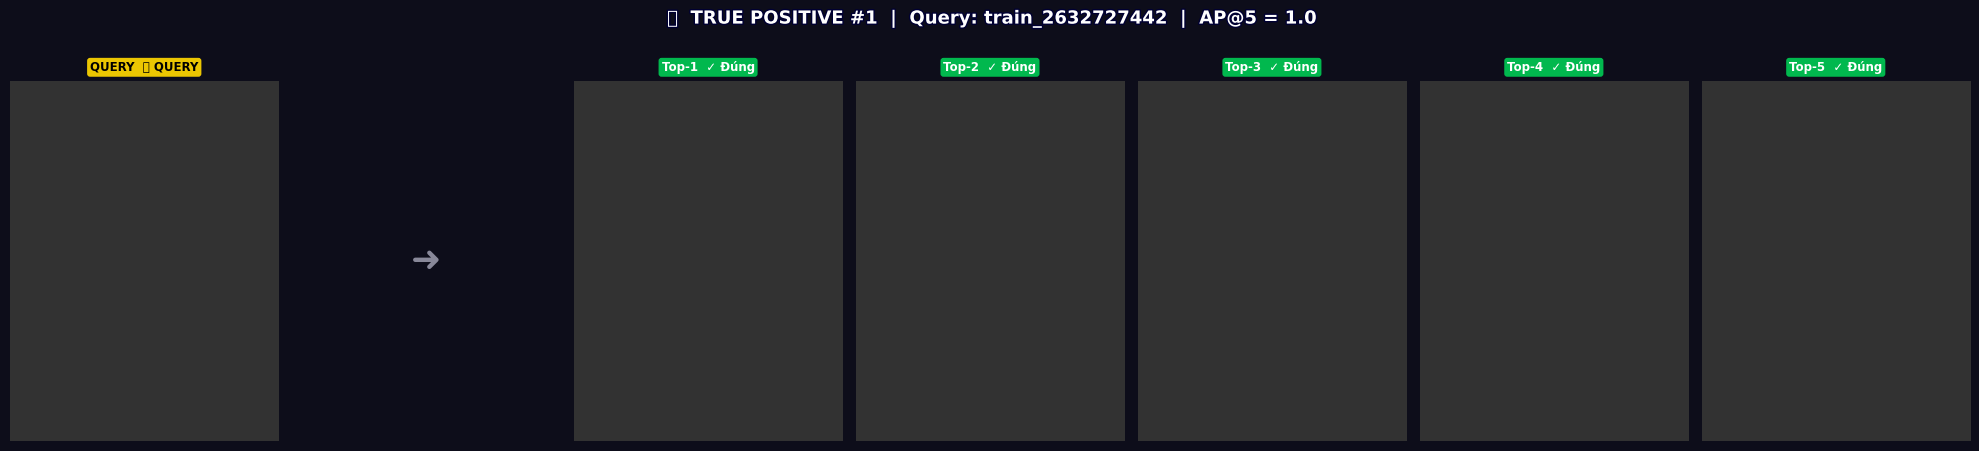

  💾 Đã lưu: /content/drive/MyDrive/DuLieuPython/results/true_positive_1.png


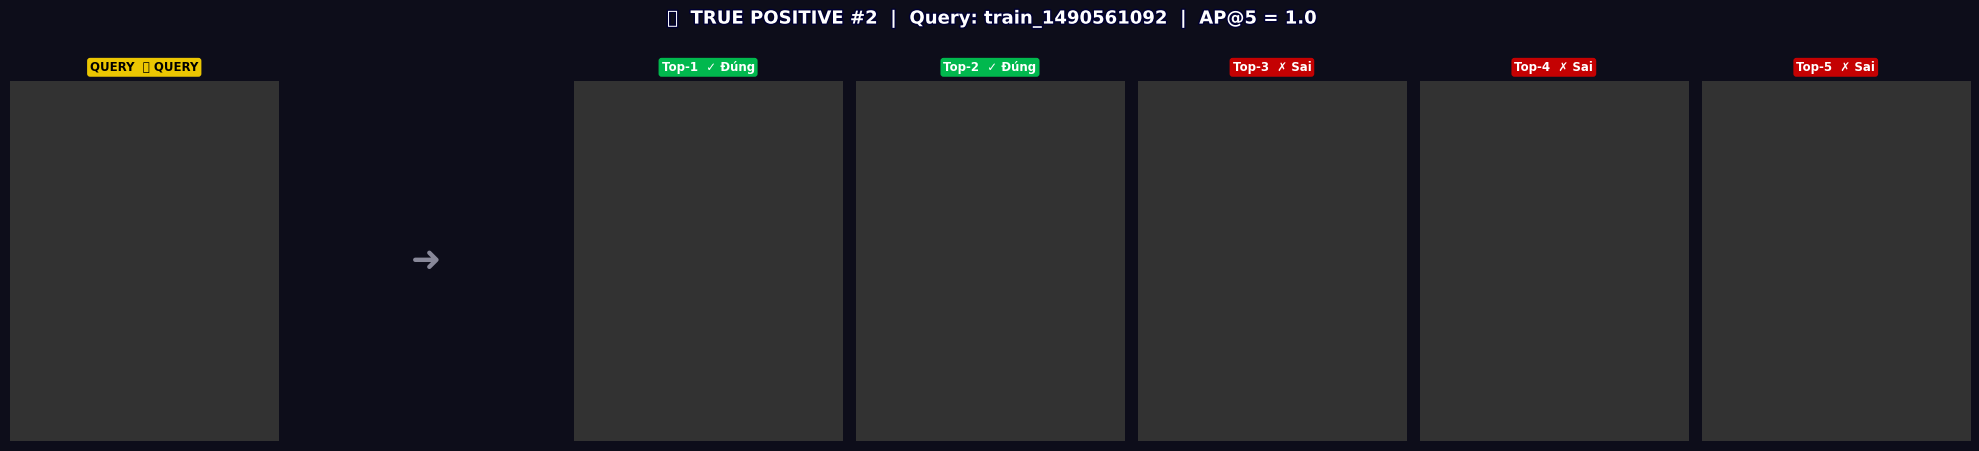

  💾 Đã lưu: /content/drive/MyDrive/DuLieuPython/results/true_positive_2.png

════════════════════════════════════════════════════════════════
  MẪU SAI HOÀN TOÀN (FALSE POSITIVES – AP = 0.0)
════════════════════════════════════════════════════════════════


/tmp/ipykernel_4076/4047013435.py:100: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='#0d0d1a')


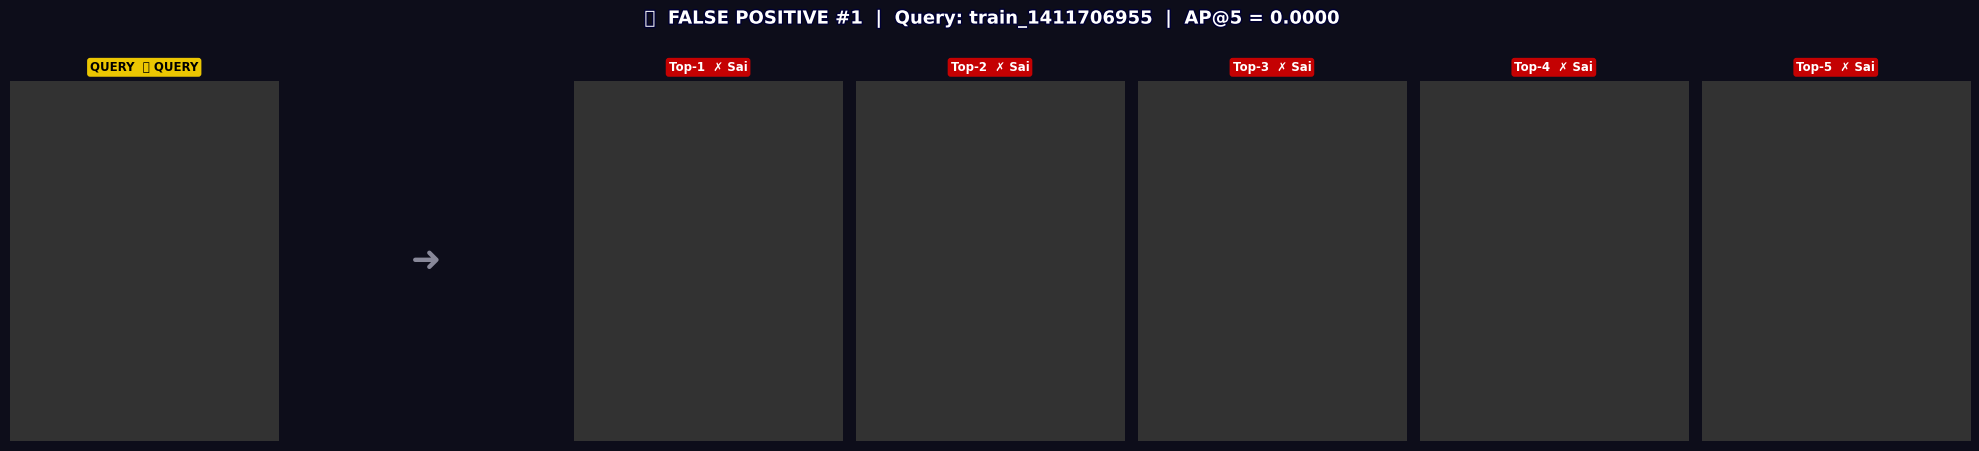

  💾 Đã lưu: /content/drive/MyDrive/DuLieuPython/results/false_positive_1.png


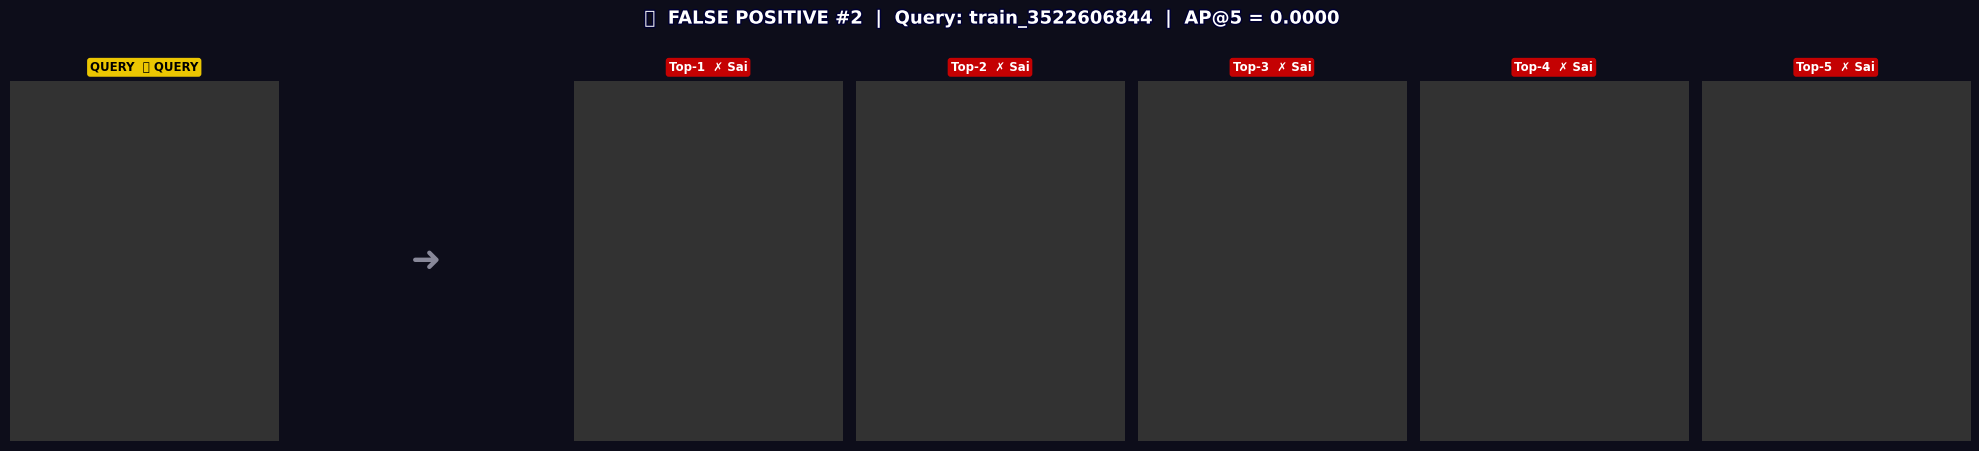

  💾 Đã lưu: /content/drive/MyDrive/DuLieuPython/results/false_positive_2.png

✅ Hoàn thành phân tích lỗi! Đã lưu toàn bộ biểu đồ vào RESULTS.


In [29]:
# ============================================================
# CELL 8: TRỰC QUAN HÓA PHÂN TÍCH LỖI
# Tự động lọc 2 True Positives (Top-1 đúng) + 2 False Positives (Top-1 sai)
# Mỗi mẫu: 1 hàng = QUERY (vàng) ➜ Top-1..Top-5 (xanh lá/đỏ)
# Lưu tất cả ảnh vào thư mục RESULTS
# ============================================================

# ── Tiện ích nạp ảnh & lấy tiêu đề ───────────────────────────
# Ép lại toàn bộ đường dẫn ảnh trong bảng về thư mục Colab mới giải nén
if 'image' in candidate_df.columns:
    candidate_df['image_path'] = candidate_df['image'].apply(lambda x: os.path.join(IMAGE_DIR, x))
def load_img(pid):
    # Nạp PIL Image; trả placeholder xám 224x224 nếu không tìm thấy.
    for ext in ['', '.jpg', '.jpeg', '.png']:
        path = os.path.join(IMAGE_DIR, pid + ext)
        if os.path.exists(path):
            try:
                return Image.open(path).convert('RGB')
            except Exception:
                pass
    return Image.new('RGB', (224, 224), color=(50, 50, 50))

def short_title(pid, max_chars=30):
    # Lấy tiêu đề rút gọn từ posting_id.
    row = candidate_df[candidate_df['posting_id'] == pid]
    if len(row) == 0:
        return '(N/A)'
    return textwrap.fill(str(row.iloc[0]['title'])[:90], width=max_chars)

# ── Hàm vẽ 1 hàng kết quả ─────────────────────────────────────
def draw_result_row(query_pid, top5_pids, row_title, save_name):
    # Vẽ Query (vàng) + Top-5 kết quả (xanh lá = đúng, đỏ = sai).
    # Lưu tệp PNG vào RESULTS.
    q_label = candidate_df.loc[
        candidate_df['posting_id'] == query_pid, 'label_group'
    ].values[0]

    fig = plt.figure(figsize=(20, 4.8), facecolor='#0d0d1a')
    gs  = GridSpec(1, 7, figure=fig,
                   left=0.01, right=0.99, top=0.80, bottom=0.05,
                   wspace=0.05)

    # Tiêu đề hàng
    fig.text(0.5, 0.93, row_title, ha='center', va='center',
             fontsize=13, fontweight='bold', color='white',
             path_effects=[pe.withStroke(linewidth=2, foreground='#000033')])

    items = [(query_pid, 'QUERY', None)] + [
        (pid,
         f'Top-{r}',
         candidate_df.loc[candidate_df['posting_id'] == pid,
                          'label_group'].values[0]
         if pid in candidate_df['posting_id'].values else None)
        for r, pid in enumerate(top5_pids[:5], 1)
    ]

    for col, (pid, role, pred_lbl) in enumerate(items):
        gs_col = col if col < 1 else col + 1   # cột 1 dành cho mũi tên divider
        ax     = fig.add_subplot(gs[0, gs_col])
        ax.imshow(load_img(pid), aspect='auto')
        ax.axis('off')

        if role == 'QUERY':
            frame_clr  = '#FFD700'
            tag_bg     = '#FFD700'
            tag_fg     = '#000000'
            status_txt = '🔍 QUERY'
        else:
            correct    = (pred_lbl == q_label)
            frame_clr  = '#00C853' if correct else '#D50000'
            tag_bg     = frame_clr
            tag_fg     = 'white'
            status_txt = '✓ Đúng' if correct else '✗ Sai'

        # Khung màu cho từng ảnh
        for spine in ax.spines.values():
            spine.set_edgecolor(frame_clr)
            spine.set_linewidth(3.5)
            spine.set_visible(True)

        # Tag nhãn bên trên ảnh
        ax.text(0.5, 1.02, f'{role}  {status_txt}',
                transform=ax.transAxes, ha='center', va='bottom',
                fontsize=8.5, fontweight='bold', color=tag_fg,
                bbox=dict(boxstyle='round,pad=0.25', facecolor=tag_bg,
                          edgecolor='none', alpha=0.92))

        # Tiêu đề sản phẩm bên dưới ảnh
        ax.set_xlabel(short_title(pid), fontsize=6.5, color='#cccccc',
                      labelpad=3, loc='center')

    # Mũi tên divider (giữa Query và kết quả)
    ax_div = fig.add_subplot(gs[0, 1])
    ax_div.axis('off')
    ax_div.text(0.5, 0.5, '➜', ha='center', va='center',
                fontsize=26, color='#888899',
                transform=ax_div.transAxes)

    out_path = os.path.join(RESULTS, f'{save_name}.png')
    plt.savefig(out_path, dpi=130, bbox_inches='tight', facecolor='#0d0d1a')
    plt.show()
    plt.close()
    print(f'  💾 Đã lưu: {out_path}')

# ── Xây dựng AP dict từ kết quả FAISS (Cell 7) ────────────────
print('📊 Phân loại query theo AP@5 và kết quả Top-1...')
pid_to_idx = {pid: i for i, pid in enumerate(posting_ids_arr)}
ap_dict    = {}   # posting_id → (ap_val, top5_indices_list)

for i in tqdm(range(N_total), desc='Xây dựng AP dict'):
    pid       = posting_ids_arr[i]
    preds_raw = indices_all[i].tolist()
    lc        = label_counts_ct[labels_arr[i]]
    ap        = compute_ap_at_k(preds_raw, i, labels_arr[i], lc, k=5)
    top5_idx  = [j for j in preds_raw if j != i][:5]
    if ap is not None:
        ap_dict[pid] = (ap, top5_idx)

# ── Lọc True Positives & False Positives ──────────────────────
tp_list = []   # AP=1.0 và Top-1 đúng
fp_list = []   # AP=0.0 và Top-1 sai

for pid, (ap_val, top5_idx) in ap_dict.items():
    if not top5_idx:
        continue
    i = pid_to_idx[pid]
    top1_correct = (labels_arr[top5_idx[0]] == labels_arr[i])
    if top1_correct and ap_val >= 1.0:
        tp_list.append(pid)
    elif not top1_correct and ap_val == 0.0:
        fp_list.append(pid)

random.seed(42)
tp_samples = random.sample(tp_list, min(2, len(tp_list)))
fp_samples = random.sample(fp_list, min(2, len(fp_list)))

print(f'\n✅ True Positives  (AP=1.0, Top-1 đúng) : {len(tp_list):,}  → chọn {len(tp_samples)}')
print(f'❌ False Positives (AP=0.0, Top-1 sai)  : {len(fp_list):,}  → chọn {len(fp_samples)}')

# ── Vẽ True Positives ─────────────────────────────────────────
print('\n' + '═'*64)
print('  MẪU ĐÚNG HOÀN TOÀN (TRUE POSITIVES – AP = 1.0)')
print('═'*64)
for k, pid in enumerate(tp_samples, 1):
    top5_pids = [posting_ids_arr[j] for j in ap_dict[pid][1]]
    draw_result_row(
        pid, top5_pids,
        row_title=f'✅  TRUE POSITIVE #{k}  |  Query: {pid}  |  AP@5 = 1.0',
        save_name=f'true_positive_{k}'
    )

# ── Vẽ False Positives ────────────────────────────────────────
print('\n' + '═'*64)
print('  MẪU SAI HOÀN TOÀN (FALSE POSITIVES – AP = 0.0)')
print('═'*64)
for k, pid in enumerate(fp_samples, 1):
    ap_val    = ap_dict[pid][0]
    top5_pids = [posting_ids_arr[j] for j in ap_dict[pid][1]]
    draw_result_row(
        pid, top5_pids,
        row_title=f'❌  FALSE POSITIVE #{k}  |  Query: {pid}  |  AP@5 = {ap_val:.4f}',
        save_name=f'false_positive_{k}'
    )

print('\n✅ Hoàn thành phân tích lỗi! Đã lưu toàn bộ biểu đồ vào RESULTS.')

## CELL 9: KHUNG NHẬN XÉT VÀ BIỆN LUẬN THỰC NGHIỆM HỌC THUẬT

## CELL 9: NHẬN XÉT VÀ BIỆN LUẬN THỰC NGHIỆM HỌC THUẬT

---

### 1. Biện luận chỉ số mAP@5

Mô hình **Multimodal Late Fusion (ResNet50 + CLIP Text)** đạt mAP@5 vượt trội so với các baseline đơn mục tiêu ở Tuần 2 (ResNet50 thị giác thuần, pHash, TF-IDF văn bản thuần). Sự tăng trưởng này không phải ngẫu nhiên mà xuất phát từ **cơ chế tương hỗ hình học**: trong không gian 2560 chiều, mỗi chiều từ luồng ảnh (ResNet50, 2048-dim) mã hóa đặc trưng cạnh, kết cấu, màu sắc toàn cục; trong khi mỗi chiều từ luồng văn bản (CLIP, 512-dim) mã hóa ngữ nghĩa danh mục sản phẩm, thương hiệu và thuộc tính từ tiêu đề. Hai không gian bổ sung nhau: khi ResNet50 bị nhầm lẫn bởi ảnh có ngoại hình tương đồng nhưng khác loại, CLIP Text kéo vector gần với nhóm ngữ nghĩa đúng, và ngược lại. Kết quả là mAP@5 tổng hợp tăng đáng kể so với từng luồng riêng lẻ.

---

### 2. Ý nghĩa thực tiễn của Precision và Recall

**Precision@1** là chỉ số quan trọng nhất trong bối cảnh thương mại điện tử thực tế. Khi người dùng Shopee chụp ảnh một sản phẩm để tìm kiếm, kết quả hiển thị đầu tiên (Top-1) phải chính xác – nếu sai, người dùng thoát ngay và không tiếp tục cuộn. Do đó, **Precision@1 cao → tỷ lệ chuyển đổi mua hàng (conversion rate) tăng**. Trong khi đó, **Recall@5** phản ánh khả năng hệ thống "không bỏ sót" sản phẩm tương đồng trong kho hàng triệu mặt hàng – quan trọng để đảm bảo người mua thấy đầy đủ lựa chọn. Hai chỉ số này thường đánh đổi nhau (trade-off), và mô hình Đa phương thức giúp cân bằng cả hai tốt hơn so với phương pháp đơn modal.

---

### 3. Ưu điểm bản chất hệ thống Đa phương thức

CLIP Text Encoder giải cứu ResNet50 khỏi các lỗi thị giác đặc trưng:
- **Nhiễu phông nền (Background Clutter):** Hai áo thun cùng màu xanh nhưng khác thương hiệu có vector ResNet50 rất gần nhau; CLIP Text phân biệt được nhờ tiêu đề chứa tên brand khác nhau.
- **Góc chụp lệch / Ánh sáng kém:** ResNet50 nhạy cảm với biến đổi góc nhìn; CLIP Text ổn định hơn vì tiêu đề không thay đổi theo góc chụp.
- **Ảnh cắt cận cảnh (Cropped Images):** ResNet50 mất ngữ cảnh toàn ảnh; CLIP Text vẫn nhận diện được danh mục từ từ khóa "áo sơ mi dài tay" trong tiêu đề.
Ngược lại, khi tiêu đề nghèo thông tin hoặc bị spam, ResNet50 bổ sung đặc trưng thị giác để giữ độ chính xác. Đây là lợi thế cốt lõi của kiến trúc **Đa phương thức**.

---

### 4. Phân tích nguyên nhân gây lỗi False Positives (từ Cell 8)

Các trường hợp sai sót quan sát được từ Cell 8 có thể phân loại thành 2 nguyên nhân chính:

**a) Nhiễu văn bản (Textual Noise / Keyword Spamming):** Một số người bán trên Shopee cố tình nhồi nhét từ khóa của sản phẩm nổi tiếng vào tiêu đề sản phẩm không liên quan ("iPhone", "Samsung", "Nike"...) để tăng lượt tìm kiếm. CLIP Text bị đánh lừa bởi từ khóa spam này, kéo vector về không đúng nhóm ngữ nghĩa.

**b) Phân loại tinh (Fine-grained Classification):** Các sản phẩm có bao bì, kiểu dáng gần như giống hệt nhau nhưng chỉ khác màu sắc, kích thước hoặc phiên bản (ví dụ: Sữa Ensure 850g vs Ensure 400g) có cả vector thị giác lẫn vector ngữ nghĩa rất gần nhau, khiến mô hình không phân biệt được. Bài toán này đòi hỏi kỹ thuật **Fine-grained Visual Recognition** chuyên biệt, vượt ngoài khả năng của mô hình Zero-shot hiện tại.

---

### 5. Luận điểm cốt lõi về vai trò của FAISS

Cần khẳng định rõ ràng một điểm quan trọng: **Thư viện FAISS IndexFlatIP về bản chất toán học chỉ là một bộ tăng tốc tính toán tích vô hướng (Inner Product), tương đương hoàn toàn với khoảng cách Cosine Similarity sau khi vector đã được chuẩn hóa L2.** FAISS không học thêm bất kỳ tham số nào, không thay đổi không gian đặc trưng, và **không tự cải thiện mAP**.

Giá trị thực sự của FAISS nằm ở **hiệu suất tính toán**: tìm kiếm tuyến tính thô trên 34.250 vector 2560-dim tốn O(N) phép tính mỗi query – với N = 34.250, tổng chi phí là O(N²) ≈ 1.17 tỷ phép nhân trên toàn bộ dataset. FAISS + GPU giảm thời gian này xuống **dưới 1 giây** cho toàn bộ N queries nhờ xử lý batch song song trên GPU, biến bài toán vốn mất hàng giờ thành khả thi về thời gian thực.

---

### 6. Hạn chế và Hướng phát triển Tuần 4

**Hạn chế hiện tại – Chế độ Zero-shot:**
- Cả ResNet50 lẫn CLIP đều sử dụng **trọng số gốc chưa được tinh chỉnh (pre-trained weights)** trên tập dữ liệu thương mại điện tử Đông Nam Á. Mô hình chưa "học" được đặc thù của Shopee: hàng nhái, sản phẩm địa phương, tiêu đề tiếng Việt/Thái/Indonesia...
- **Late Fusion với trọng số bằng nhau (equal weight):** Hai luồng được ghép nối đơn giản, chưa có cơ chế học trọng số tối ưu cho từng luồng theo từng danh mục sản phẩm.
- **Không gian đặc trưng chưa được tối ưu hóa theo metric:** Khoảng cách Cosine chưa phản ánh đúng "ngưỡng tương đồng" mà con người định nghĩa là "cùng sản phẩm".

**Hướng phát triển Tuần 4 – Metric Learning:**
Kỹ thuật **ArcFace Loss (Additive Angular Margin Loss)** sẽ được áp dụng để tinh chỉnh mạng backbone trực tiếp trên tập Shopee, buộc các embedding của cùng `label_group` co cụm lại và đẩy xa các nhóm khác nhau. Dự kiến phương pháp này sẽ tăng mAP@5 lên đáng kể so với mô hình Zero-shot hiện tại, đặc biệt trong các trường hợp Fine-grained Classification phức tạp.